# Cross-Species Cancer Genomics Pipeline
## Dog vs Human Mammary Tumor Classification using Shared Orthologous Genes

**Research Question:** Can a classifier trained on human TCGA-BRCA breast cancer gene expression
correctly classify canine mammary tumor malignancy using shared orthologous genes?

**Datasets:**
- Human: TCGA-BRCA (1100 samples, PAM50 subtypes) via UCSC Xena
- Canine: Kim et al. 2020 / PRJNA489087 (154 canine mammary tumors)

**Pipeline steps:**
1. Download TCGA-BRCA (human)
2. Download canine mammary tumor data
3. Orthologous gene mapping via Ensembl BioMart
4. Preprocessing + batch normalisation
5. ML classification + ablation study

**Runtime:** ~45-90 mins total (mostly download time)

**Colab GPU:** Not required. CPU is sufficient.

In [1]:
# ============================================================
# CELL 0: Install all dependencies
# Run this cell first, then restart runtime if prompted
# ============================================================
!pip install pandas numpy requests tqdm scikit-learn xgboost matplotlib seaborn scipy -q
print('All packages installed.')

All packages installed.



[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
# ============================================================
# CELL 1: Create directory structure
# ============================================================
import os
for d in ['data/human','data/canine','data/aligned','outputs/figures']:
    os.makedirs(d, exist_ok=True)
print('Directories ready.')

Directories ready.


In [3]:
# ============================================================
# CELL 2: STEP 1 — Download TCGA-BRCA
# Downloads ~300MB. Takes 5-15 minutes depending on connection.
# ============================================================
%run 01_download_tcga_brca.py

Directories created.
  TCGA-BRCA expression matrix -> data/human/TCGA_BRCA_expression.tsv.gz


100%|██████████| 83.4M/83.4M [00:27<00:00, 2.99MB/s]


  Done: data/human/TCGA_BRCA_expression.tsv.gz
  TCGA-BRCA clinical metadata -> data/human/TCGA_BRCA_clinical.tsv


100%|██████████| 1.70M/1.70M [00:01<00:00, 1.03MB/s]


  Done: data/human/TCGA_BRCA_clinical.tsv

Loading TCGA-BRCA expression matrix ...
  Shape (genes x samples): (20530, 1218)
  First 5 genes: ['ARHGEF10L', 'HIF3A', 'RNF17', 'RNF10', 'RNF11']
  First 3 sample IDs: ['TCGA-AR-A5QQ-01', 'TCGA-D8-A1JA-01', 'TCGA-BH-A0BQ-01']

Clinical metadata shape: (1247, 193)
Available columns (first 10): ['AJCC_Stage_nature2012', 'Age_at_Initial_Pathologic_Diagnosis_nature2012', 'CN_Clusters_nature2012', 'Converted_Stage_nature2012', 'Days_to_Date_of_Last_Contact_nature2012', 'Days_to_date_of_Death_nature2012', 'ER_Status_nature2012', 'Gender_nature2012', 'HER2_Final_Status_nature2012', 'Integrated_Clusters_no_exp__nature2012']
PAM50 subtypes extracted from clinical file.
subtype
LumA      434
LumB      194
Basal     142
Normal    119
Her2       67
Name: count, dtype: int64

Subtype labels saved.

Total samples: 1218
Tumor samples (suffix -01): 1097
Normal samples (suffix -11): 114
Expression matrix after keeping tumor+normal: (20530, 1211)

Tumor/Norma

In [4]:
# ============================================================
# CELL 3: STEP 2 — Download Canine Mammary Tumor Data
# Option A: Figshare (pre-processed FPKM) — fast ~50MB
# Option B: If Figshare fails, manual GEO download instructions printed
# ============================================================
%run 02_download_canine.py

  Already exists: data/canine/GSE119810_CMT_222S_FPKM.csv.gz

NOTE: If Option A download fails:
  1. Go to https://www.ncbi.nlm.nih.gov/geo/query/acc.cgi?acc=GSE119810
  2. Scroll to 'Supplementary file'
  3. Download: GSE119810_CMT_222S_FPKM.csv.gz
  4. Place it in: data/canine/GSE119810_CMT_222S_FPKM.csv.gz

Loading canine mammary tumor expression matrix ...
  Shape (genes x samples): (24580, 222)
  First 5 gene IDs: ['ENSCAFG00000000001', 'ENSCAFG00000000002', 'ENSCAFG00000000005', 'ENSCAFG00000000006', 'ENSCAFG00000000007']
  First 3 samples: ['CMT-002-tumor', 'CMT-003-tumor', 'CMT-008-normal']

Canine metadata shape: (222, 1)
Tumor/normal distribution:
malignancy
tumor     158
normal     64
Name: count, dtype: int64

Sample canine gene IDs:
['ENSCAFG00000000001', 'ENSCAFG00000000002', 'ENSCAFG00000000005', 'ENSCAFG00000000006', 'ENSCAFG00000000007', 'ENSCAFG00000000008', 'ENSCAFG00000000009', 'ENSCAFG00000000010', 'ENSCAFG00000000011', 'ENSCAFG00000000012']
  Format: Ensembl canin

In [5]:
# ============================================================
# CELL 4: STEP 3 — Orthologous Gene Mapping
# Queries Ensembl BioMart REST API (~3 min)
# Filters to one-to-one orthologs with >50% identity
# Aligns both matrices on shared genes
# ============================================================
%run 03_ortholog_mapping.py

  (this file covers dog-vs-all-species homology; may take a minute) ...
  Downloaded OK. Raw shape: (3352851, 15)
  No human homology rows found in this file - trying next release ...
  (this file covers dog-vs-all-species homology; may take a minute) ...
  File wasn't valid gzip/TSV (probably a 404 HTML page) - trying next release ...
  (this file covers dog-vs-all-species homology; may take a minute) ...
  Downloaded OK. Raw shape: (4471087, 15)
  Human homology rows: (7830, 15)
  SUCCESS from release 102.
  Saved to cache: data/aligned/dog_human_orthologs_raw.csv

Raw ortholog table:
           dog_ensembl_id  dog_gene_symbol human_ensembl_id  \
47690  ENSCAFG00000032250              NaN  ENSG00000176294   
47834  ENSCAFG00000015460              NaN  ENSG00000182652   
47942  ENSCAFG00000023739              NaN  ENSG00000182652   
48018  ENSCAFG00000043265              NaN  ENSG00000258453   
48019  ENSCAFG00000043265              NaN  ENSG00000130538   

       human_gene_symbol   

In [6]:
# ============================================================
# CELL 5: STEP 4 — Preprocessing
# - Aligns sample labels to expression matrices
# - Filters top 3000 genes by variance
# - Z-score normalisation per species
# - PCA visualisation saved to outputs/
# ============================================================
%run 04_preprocessing.py

Loading aligned expression matrices ...
  Human  (genes x samples): (4608, 1211)
  Canine (genes x samples): (4608, 222)

Human samples with tumor/normal label: 1211 / 1211
Tumor/Normal distribution:
tumor_normal
tumor     1097
normal     114
Name: count, dtype: int64

Canine samples with metadata: 222 / 222
Canine label distribution:
malignancy
tumor     158
normal     64
Name: count, dtype: int64

Gene variance filtering:
  Total shared genes: 4608
  Keeping top 3000 by variance in CANINE data (training domain)
  X_canine shape: (222, 3000)
  X_human shape: (1211, 3000)

Applying per-gene z-score standardisation (batch normalisation) ...
  Human  mean: 0.0000, std: 1.0000
  Canine mean: 0.0000, std: 1.0000

Human label encoding: {'normal': np.int64(0), 'tumor': np.int64(1)}
Canine label encoding: {'normal': np.int64(0), 'tumor': np.int64(1)}

Saved: outputs/pca_species_subtypes.png

Final dataset summary:
  X_human:  (1211, 3000)  |  y_human classes: ['normal' 'tumor']
  X_canine: (2

In [7]:
# ============================================================
# CELL 6: STEP 5 — ML Classification + Ablation
# Experiment A: Human 5-fold CV (baseline)
# Experiment B: Train human -> predict canine (main result)
# Experiment C: Ablation: gene set size comparison
# Saves 4 thesis-quality figures + results CSV
# ============================================================
%run 05_classification_ablation.py

Loading preprocessed data ...
X_human:  (1211, 3000)  |  Classes: ['0', 'normal', 'tumor']
X_canine: (222, 3000)  |  Classes: ['0', 'normal', 'tumor']

EXPERIMENT A: Within-canine 5-fold cross-validation
  XGBoost: F1-macro = 0.8656 ± 0.0490
  Random Forest: F1-macro = 0.8582 ± 0.0399
  SVM: F1-macro = 0.8594 ± 0.0237
  MLP: F1-macro = 0.8600 ± 0.0488

EXPERIMENT B: Train on CANINE CMT, Predict on HUMAN TCGA-BRCA
(Core question: do gene expression patterns learned from canine
 mammary tumors transfer to predicting human breast cancer?)

Canine training label distribution (0=normal, 1=tumor):
1    158
0     64
Name: count, dtype: int64

Human evaluation label distribution (0=normal, 1=tumor):
1    1097
0     114
Name: count, dtype: int64
NOTE: human side is naturally imbalanced (~90% tumor, ~10% normal) -
      F1-macro (used below) is more robust to this than accuracy.

  XGBoost:
    Accuracy:  0.8712
    F1-macro:  0.4898
    ROC-AUC:   0.8076
    Report:
              precision    r


--- outputs/figures\fig1_confusion_matrix.png ---


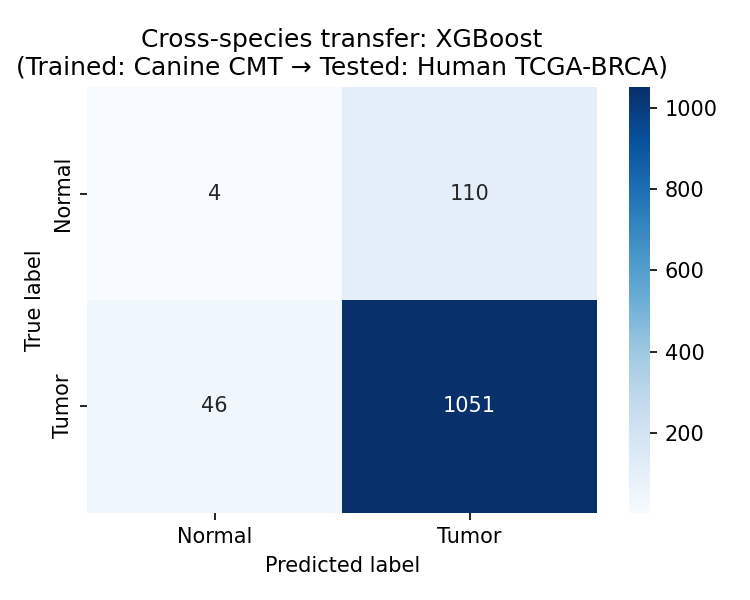


--- outputs/figures\fig2_ablation.png ---


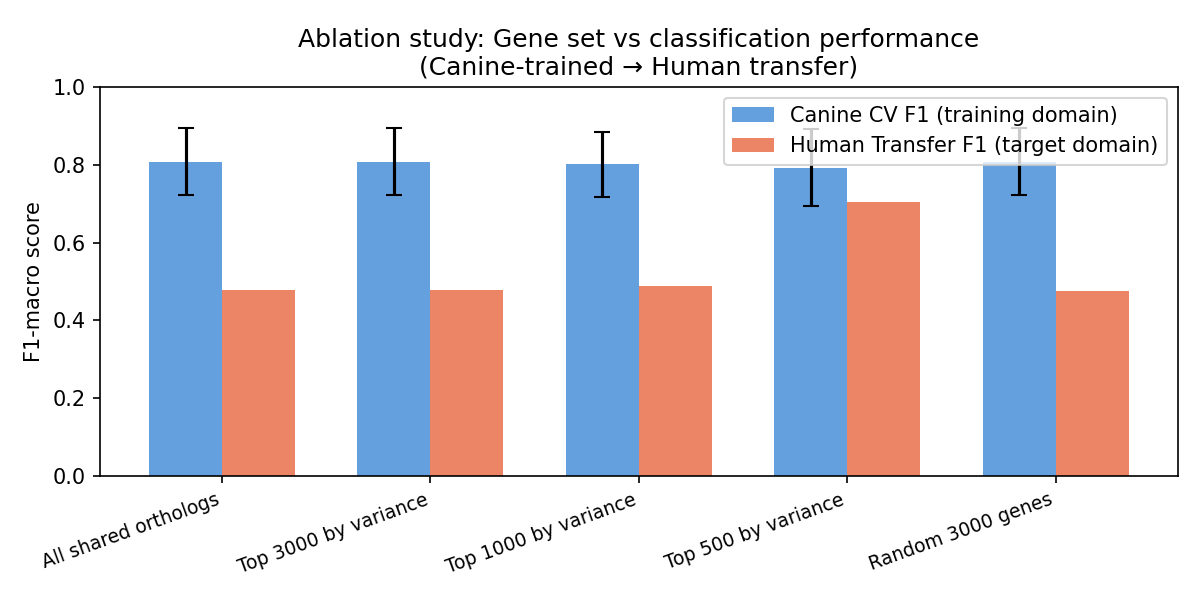


--- outputs/figures\fig3_feature_importance.png ---


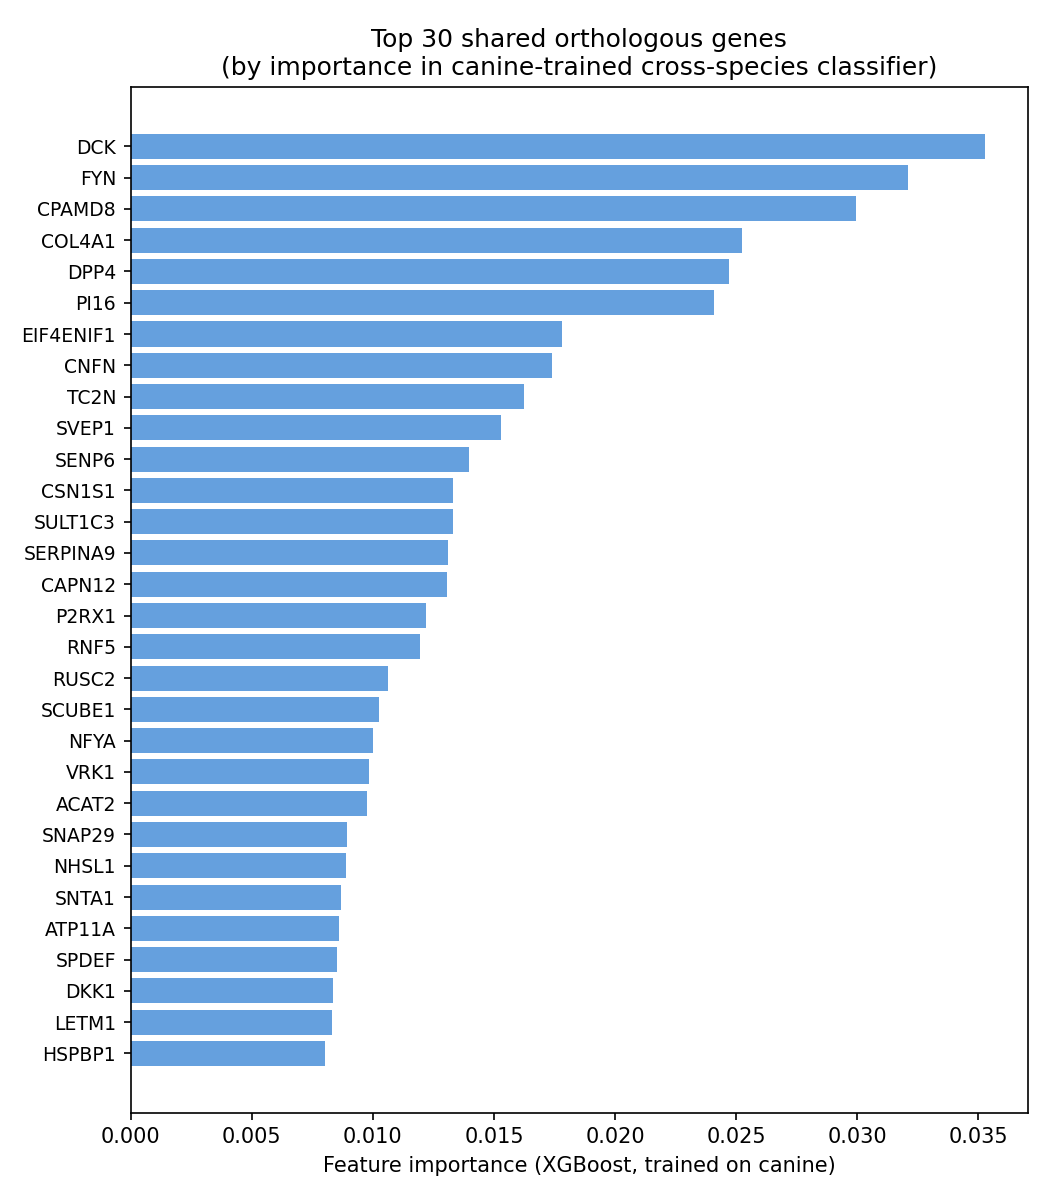


--- outputs/figures\fig4_model_comparison.png ---


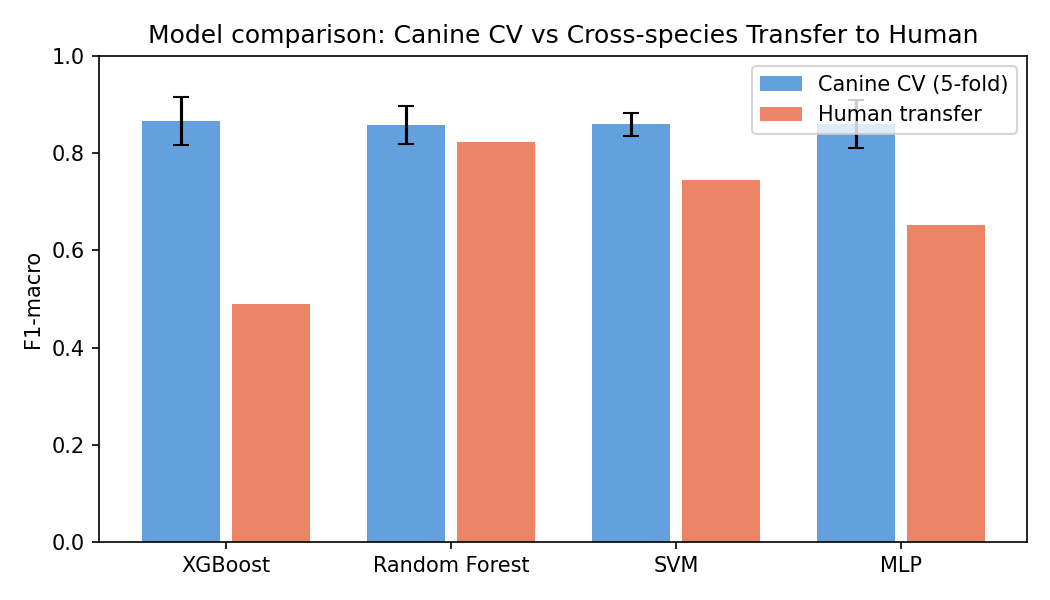

In [8]:
# ============================================================
# CELL 7: View all output figures inline
# ============================================================
from IPython.display import Image, display
import glob

figs = sorted(glob.glob('outputs/figures/*.png'))
for f in figs:
    print(f'\n--- {f} ---')
    display(Image(f))

In [9]:
# ============================================================
# CELL 8: Print final results summary
# ============================================================
import pandas as pd
summary = pd.read_csv('outputs/results_summary.csv')
print('=== FINAL RESULTS SUMMARY ===')
print(summary.to_string(index=False))

ablation = pd.read_csv('outputs/ablation_results.csv', index_col=0)
print('\n=== ABLATION STUDY RESULTS ===')
print(ablation.to_string())

=== FINAL RESULTS SUMMARY ===


        Model  Canine CV F1 (mean)  Canine CV F1 (std)  Human Transfer F1  Human Transfer AUC
      XGBoost               0.8656              0.0490             0.4898              0.8076
Random Forest               0.8582              0.0399             0.8220              0.9674
          SVM               0.8594              0.0237             0.7457              0.9549
          MLP               0.8600              0.0488             0.6514              0.8854

=== ABLATION STUDY RESULTS ===
                      n_genes  canine_cv_f1  canine_cv_std  human_transfer_f1
All shared orthologs   3000.0      0.808265       0.085719           0.476867
Top 3000 by variance   3000.0      0.808265       0.085719           0.476867
Top 1000 by variance   1000.0      0.801142       0.083832           0.487696
Top 500 by variance     500.0      0.792832       0.098297           0.704967
Random 3000 genes      3000.0      0.808265       0.085719           0.475223


## Output Files

| File | Description |
|---|---|
| `outputs/results_summary.csv` | Model comparison table (for paper Table 1) |
| `outputs/ablation_results.csv` | Ablation study table (for paper Table 2) |
| `outputs/figures/fig1_confusion_matrix.png` | Confusion matrix on canine data |
| `outputs/figures/fig2_ablation.png` | Gene set ablation bar chart |
| `outputs/figures/fig3_feature_importance.png` | Top 30 shared genes by importance |
| `outputs/figures/fig4_model_comparison.png` | Human CV vs canine transfer F1 |
| `outputs/pca_species_subtypes.png` | PCA: species separation check |
| `data/aligned/shared_ortholog_genes.csv` | Final gene list used in analysis |

## Citation

- Human data: TCGA Network (2012). Nature. doi:10.1038/nature11412
- Canine data: Kim et al. (2020). Nature Communications. doi:10.1038/s41467-020-17458-0
- Ortholog mapping: Ensembl BioMart (Cunningham et al. 2022)
- XGBoost: Chen & Guestrin (2016). KDD. doi:10.1145/2939672.2939785